# Minichallenge 2 Notebook 2
Dieses Notbook enthält die Abgaben für die Tage 5 - 8 für die GBSV Minichallenge 2. Der Code sowie die Daten sind in einem GitHub Repository verfügbar und unter diesem Link zu finden: [GitHub Repository](https://github.com/adrianmeier2002/gbsv_minichallenges).

## Tag 5: Mustererkennung und Algorithmus


In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from itertools import product
import pandas as pd

In [41]:
def canny_edge_analysis(img_path, blur_ksize=(5,5), blur_sigma=1.4, thresh1=50, thresh2=150, show=True):
    """
    Führt einen vollständigen Canny-Edge-Workflow durch und zeigt Zwischenschritte.
    
    Parameter:
    - img_path: Pfad zum Eingabebild (Graustufen)
    - blur_ksize: Kernelgröße für Gaussian Blur
    - blur_sigma: Sigma für Gaussian Blur
    - thresh1, thresh2: Canny Schwellenwerte
    - show: Bool, ob die Plots angezeigt werden sollen
    
    Rückgabe:
    - Dictionary mit Zwischenschritten:
        'img', 'blur', 'magnitude', 'direction', 'edges'
    """
    # --- 1. Bild laden ---
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"{img_path} nicht gefunden")
    
    # --- 2. Gaussian Blur ---
    blur = cv2.GaussianBlur(img, blur_ksize, blur_sigma)
    
    # --- 3. Gradientenberechnung ---
    Gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx)
    
    # --- 4. Canny Edge Detection ---
    edges = cv2.Canny(blur, threshold1=thresh1, threshold2=thresh2)
    
    # --- 5. Visualisierung ---
    if show:
        plt.figure(figsize=(14,8))

        plt.subplot(2,4,1)
        plt.imshow(img, cmap='gray')
        plt.title("Original")
        plt.axis('off')

        plt.subplot(2,4,2)
        plt.imshow(blur, cmap='gray')
        plt.title("Gaussian Blur")
        plt.axis('off')

        plt.subplot(2,4,3)
        plt.imshow(Gx, cmap='gray')
        plt.title("Sobel Gradient in x-Richtung (Gx)")
        plt.axis('off')

        plt.subplot(2,4,4)
        plt.imshow(Gy, cmap='gray')
        plt.title("Sobel Gradient in y-Richtung (Gy)")
        plt.axis('off')

        plt.subplot(2,4,5)
        plt.imshow(magnitude, cmap='gray')
        plt.title("Gradient Magnitude")
        plt.axis('off')

        plt.subplot(2,4,6)
        plt.imshow(direction, cmap='twilight')
        plt.title("Gradient Direction")
        plt.axis('off')

        plt.subplot(2,4,7)
        plt.imshow(edges, cmap='gray')
        plt.title("Canny Edges")
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    
    return {'img': img, 'blur': blur, 'magnitude': magnitude, 'direction': direction, 'edges': edges}

Der Canny Edge Detection Algorithmus funktioniert in 5 Schritten:
1. Graustufen und Rauschunterdrückung: Das Bild wird in Graustufen umgewandelt und mit einem Gaussschen Filter geglättet, um Rauschen zu reduzieren.
2. Gradientenberechnung (Sobel-Filter): Die Intensitätsänderungen im Bild werden mit Sobel-Filtern in x- und y-Richtung berechnet, um die Gradientenstärke und -richtung zu bestimmen.
3. Nicht-Maximum-Suppression: Die Kanten werden auf die lokalen Maxima in Richtung des Gradienten reduziert, um dünne Kantenlinien zu erhalten.
4. Doppelte Schwellenwertsetzung: Zwei Schwellenwerte werden festgelegt, um starke und schwache Kanten zu identifizieren.
5. Edge Tracking durch Hysterese: Schwache Kanten, die mit starken Kanten verbunden sind, werden als echte Kanten beibehalten, während andere verworfen werden.

Es können dabei verschiedene Parameter angepasst werden:
- Grösse des Gaussschen Filters: Bestimmt den Bereich in der das Bild geglättet wird.
- Sigma des Gaussschen Filters: Bestimmt die Stärke der Rauschunterdrückung.
- Schwellenwerte für die Kantenverfolgung: Bestimmen, welche Kanten als stark oder schwach betrachtet werden.


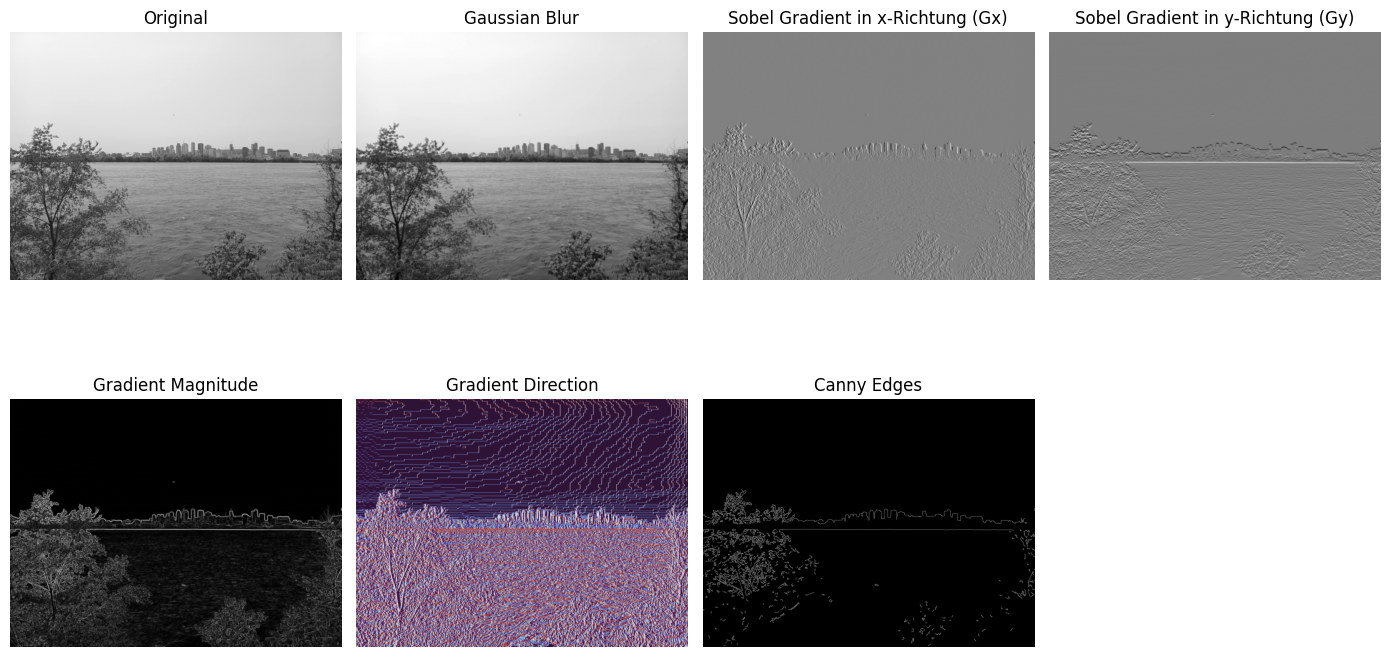

In [42]:
results = canny_edge_analysis(
    'Images/skyline_water.jpg',
    blur_ksize=(5,5),
    blur_sigma=1.5,
    thresh1=100,
    thresh2=200
)

Als Beispiel für die Anwendung des Canny Edge Detection Algorithmus wird ein weiterses Urlaubsbild von mir verwendet. Auch hier ist die Skyline gut erkennbar. Man sieht zuerst das Originalbild, danach das geglättete, etwas unscharfe Bild. Danach werden die Sobel-Filter in x- und y-Richtung angewendet, um die Gradienten zu berechnen, hier sind in X-Richtung die vertikalen Kanten der Gebäude und in Y-Richtung die horizontalen Kanten der Gebäude aber auch der Wasserspiegel gut erkennbar. Danach werden die Gradienten-Magnitude und -Richtung dargestellt. Zum Schluss wird der Canny Edge Detection Algorithmus angewendet, um die Kanten im Bild zu erkennen.

## Tag 6: Use Case
Totempfähle sind ein kulturelles Symbol der indigenen Völker Nordamerikas, insbesondere der Küsten- und Pazifik-Nordwestregion. Sie dienen als Monumente, die Geschichten, Legenden und wichtige Ereignisse der Gemeinschaften darstellen. Totempfähle sind oft kunstvoll geschnitzt und bemalt, wobei jedes Symbol und jede Figur eine spezifische Bedeutung hat.

Als Use Case für die Kantenerkennung mit dem Canny Edge Detection Algorithmus könnte die digitale Erfassung und Analyse von Totempfählen dienen. Durch die Kantenerkennung können die Umrisse und Details der geschnitzten Figuren und Symbole auf den Totempfählen hervorgehoben werden. Dies ermöglicht eine präzise digitale Repräsentation der Kunstwerke, die für Forschungszwecke, Restaurierung oder virtuelle Ausstellungen genutzt werden kann.

Das Nachfolgende Bild eignet sich deshalb gut, da es ein einzelner Totempfahl ist, in welchem der Hintergrund relativ einheitlich ist, was die Kantenerkennung erleichtert, da nur wenige Bäume oder andere Objekte im Hintergrund die Kanten stören könnten. Zudem sind die Details und Schnitzereien des Totempfahls gut erkennbar.

## Tag 7: Algorithmusanwendung
Als erstes wird die Funktion welche vorher definiert wurde auf das Bild des Totempfahls angewendet. Im Anschluss versuche ich noch die Parameter zu optimieren, um ein besseres Ergebnis zu erzielen.

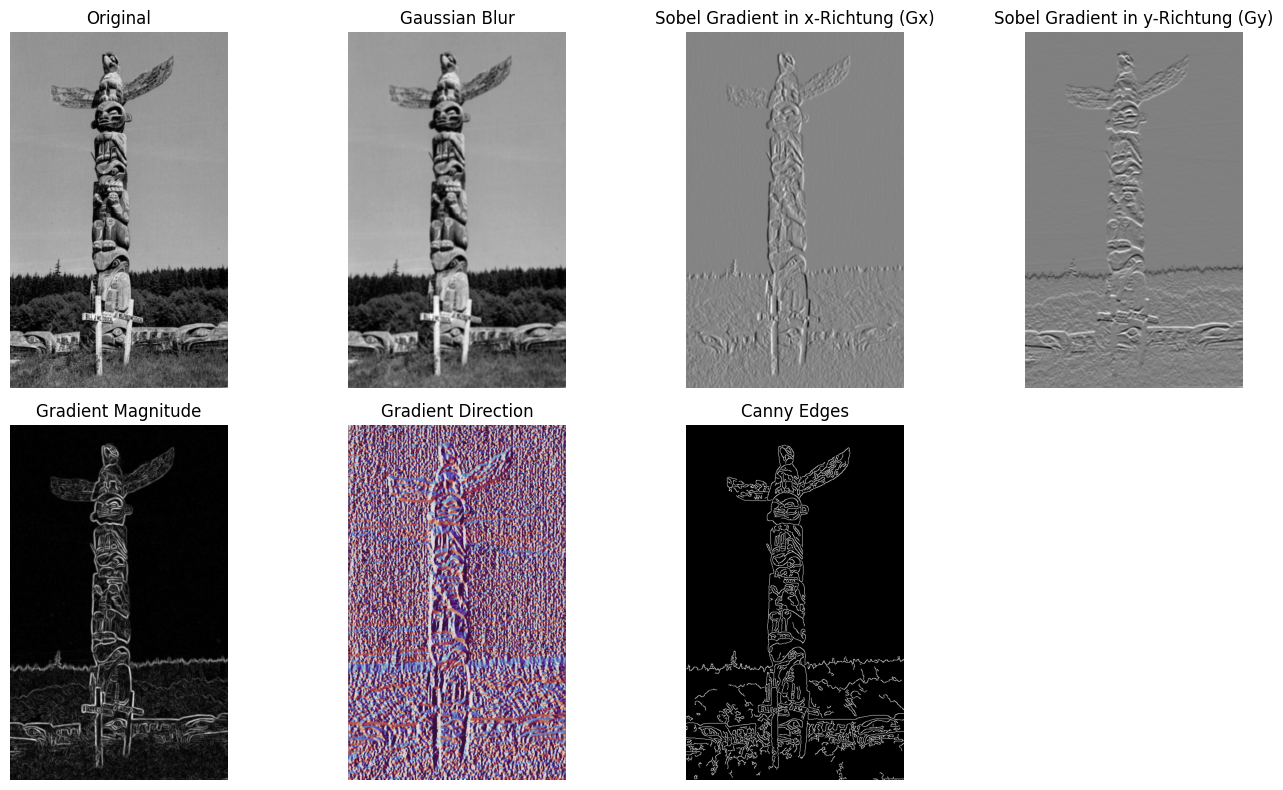

In [43]:
results = canny_edge_analysis("Images/totempole.jpg", show=True)

Top 5 Parameterkombinationen:


,blur_k,sigma,t1,t2,edge_density,mean_strength,mean_contour_len,num_contours,score
0,"(3, 3)",0.5,20,240,0.120694,165.474816,235.931256,301,0.659719
1,"(5, 5)",0.5,20,240,0.120694,165.474816,235.931256,301,0.659719
2,"(5, 5)",0.5,60,240,0.095538,189.848137,168.721528,356,0.567538
3,"(3, 3)",0.5,60,240,0.095538,189.848137,168.721528,356,0.567538
4,"(3, 3)",0.5,20,180,0.129974,160.778811,146.380575,524,0.566418


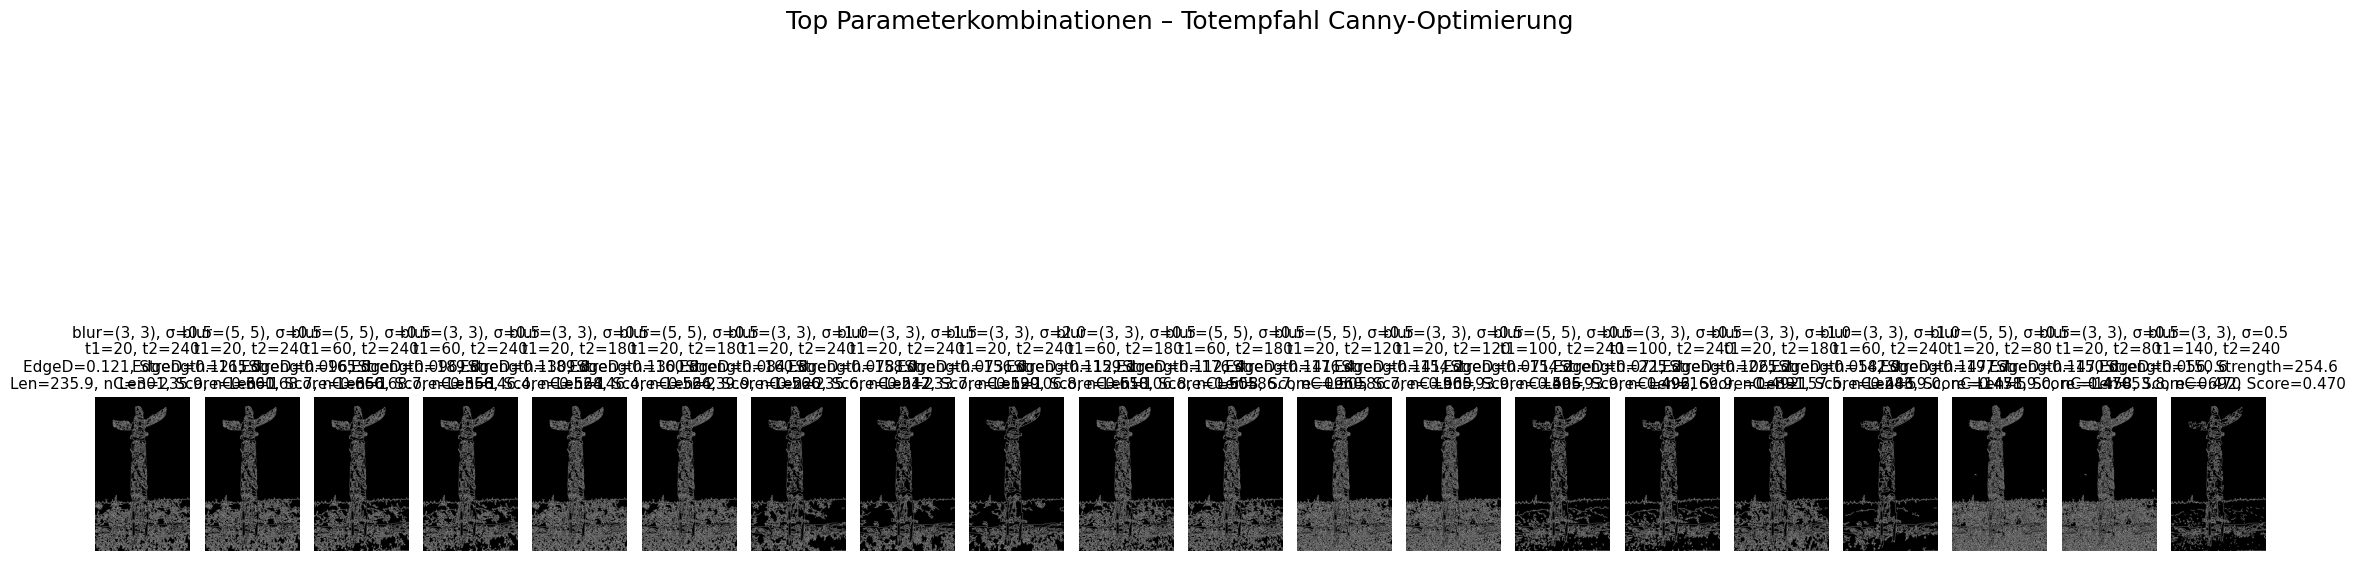

In [64]:
def compute_kpis(img_gray, edges, gradient_mag):
    h, w = img_gray.shape
    n_pixels = h * w
    edge_pixels = np.count_nonzero(edges)
    edge_density = edge_pixels / n_pixels

    if edge_pixels > 0:
        mean_strength = gradient_mag[edges > 0].mean()
    else:
        mean_strength = 0.0

    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    num_contours = len(contours)
    lengths = [cv2.arcLength(cnt, closed=False) for cnt in contours] if contours else [0]
    mean_contour_len = float(np.mean(lengths)) if lengths else 0.0
    max_contour_len = float(np.max(lengths)) if lengths else 0.0

    return {
        'edge_pixels': int(edge_pixels),
        'edge_density': float(edge_density),
        'mean_strength': float(mean_strength),
        'num_contours': int(num_contours),
        'mean_contour_len': float(mean_contour_len),
        'max_contour_len': float(max_contour_len)
    }

def normalize_series(arr):
    arr = np.array(arr, dtype=float)
    mn, mx = arr.min(), arr.max()
    if mx - mn < 1e-12:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)


# --- Parameter-Grid ---
blur_ksizes = [(3,3),(5,5)]
blur_sigmas = [0.5, 1.0, 1.5, 2.0]
thresh1_list = [20, 60, 100, 140]
thresh2_list = [80, 120, 180, 240]

# Lade Totempfahl-Bild
img_path = 'Images/totempole.jpg'
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"{img_path} nicht gefunden")

results = []

# --- Grid Search über alle Parameterkombinationen ---
for blur_k, sigma, t1, t2 in product(blur_ksizes, blur_sigmas, thresh1_list, thresh2_list):
    if t1 >= t2:
        continue

    # Canny-Workflow mit deiner Funktion (show=False!)
    res = canny_edge_analysis(
        img_path,
        blur_ksize=blur_k,
        blur_sigma=sigma,
        thresh1=t1,
        thresh2=t2,
        show=False
    )

    # Berechne KPIs
    kpis = compute_kpis(res['img'], res['edges'], res['magnitude'])

    results.append({
        'blur_k': blur_k,
        'sigma': sigma,
        't1': t1,
        't2': t2,
        **kpis,
        'edges': res['edges']
    })


# --- In DataFrame und Bewertung ---
df = pd.DataFrame(results)

df['edge_density_n'] = normalize_series(df['edge_density'])
df['mean_strength_n'] = normalize_series(df['mean_strength'])
df['mean_contour_len_n'] = normalize_series(df['mean_contour_len'])
df['num_contours_n'] = normalize_series(df['num_contours'])

# Gewichtung
w1, w2, w3, w4 = 0.35, 0.35, 0.25, 0.05
df['score'] = (w1*df['edge_density_n'] +
               w2*df['mean_strength_n'] +
               w3*df['mean_contour_len_n'] -
               w4*df['num_contours_n'])

df_sorted = df.sort_values('score', ascending=False).reset_index(drop=True)

print("Top 5 Parameterkombinationen:")
display(df_sorted.head(5)[['blur_k','sigma','t1','t2','edge_density','mean_strength','mean_contour_len','num_contours','score']])


# --- Visualisierung der Top Ergebnisse ---
topN = 20
top_rows = df_sorted.head(topN)
plt.figure(figsize=(22, 8))

for i, row in enumerate(top_rows.itertuples()):
    edges_img = row.edges
    plt.subplot(1, topN, i+1)
    plt.imshow(edges_img, cmap='gray')
    plt.axis('off')
    plt.title(
        f"blur={row.blur_k}, σ={row.sigma}\n"
        f"t1={row.t1}, t2={row.t2}\n"
        f"EdgeD={row.edge_density:.3f}, Strength={row.mean_strength:.1f}\n"
        f"Len={row.mean_contour_len:.1f}, nC={row.num_contours}, Score={row.score:.3f}",
        fontsize=11
    )

plt.suptitle("Top Parameterkombinationen – Totempfahl Canny-Optimierung", fontsize=18, y=1.03)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Hier werden die Parameter optimiert, um ein besseres Ergebnis zu erzielen. Ich habe verschiedene Kombinationen von Sigma-Werten für den Gaussschen Filter und den Schwellenwerten für die Kantenverfolgung ausprobiert. Das Ziel war es, die Kanten des Totempfahls klar und deutlich zu erkennen. Zur Auswertung der Ergebnisse habe ich folgende Metriken verwendet:

- edge_density: Verhältnis der Kantenpixel zur Gesamtanzahl der Pixel im Bild. Dabei sollte die Dichte weder zu hoch (zu viele Kanten, Rauschen) noch zu niedrig (zu wenige Kanten, wichtige Details fehlen) sein.
- mean_strength: Durchschnittliche Stärke der erkannten Kanten. Eine höhere durchschnittliche Stärke deutet auf klarere und deutlichere Kanten hin.
- mean_contour_length: Durchschnittliche Länge der erkannten Konturen. Längere Konturen können auf zusammenhängende Kanten hinweisen, was für die Erkennung von Objekten im Bild wichtig ist
- num_contours: Anzahl der erkannten Konturen im Bild. Eine moderate Anzahl von Konturen ist wünschenswert, um sicherzustellen, dass wichtige Details erfasst werden, ohne dass das Bild überladen wird.
- score: Am Ende wird ein Score berechnet, dieser setzt die verschiedenen Metriken in Relation zueinander, um eine Gesamtbewertung der Kantenerkennung zu erhalten. Dabei wird eine Gewichtung verwendet, um die Wichtigkeit der einzelnen Metriken zu berücksichtigen. Ich habe die Gewichtungen so gewählt, dass edge_density und mean_strength am wichtigsten sind, gefolgt von mean_contour_length und num_contours.

Es hat sich gezeigt, dass die Blur_k Werte fast keinen Einfluss auf die Metriken haben, weshalb ich diese auf nur 2 Parameterwerte (3 und 5) reduziert habe. Als bestes Ergebnis laut Score hat sich die Kombination von Blur_ksize = (3,3), Blur_sigma = 0.5, thresh1 = 20 und thresh2 = 240 ergeben. Wenn man jedoch das Ergebniss anschaut, sieht man dass auch viel vom Hintergrund mit erfasst wurde. Ich habe mir deshalb einmal alle Ergebnisse angeschaut und mir das für mich sinnvollste Ergebnis ausgesucht und Dargestellt.

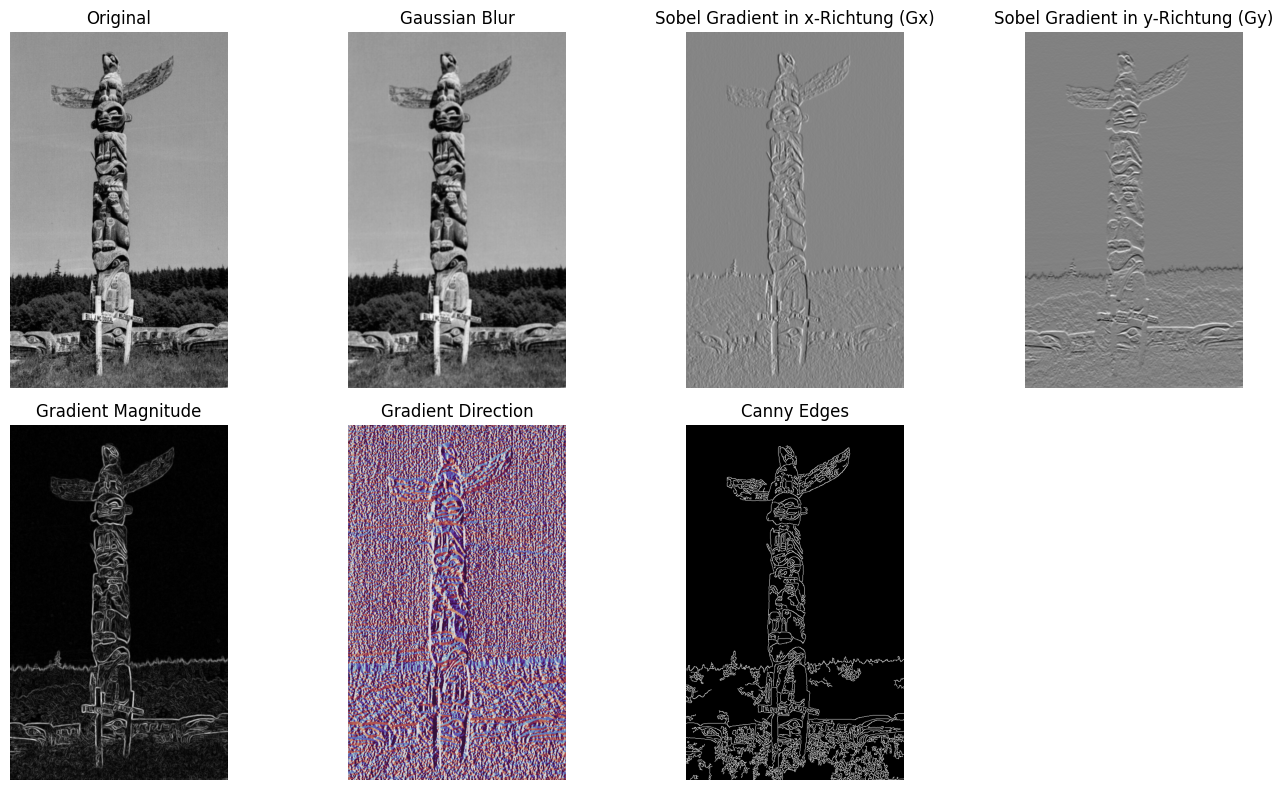

In [66]:
# Visualisierung des besten Ergebnisses
results = canny_edge_analysis(
    img_path,
    blur_ksize=(3,3),
    blur_sigma=2,
    thresh1=20,
    thresh2=240,
    show=True
)

Man sieht klar, dass die Kanten des Totempfahls gut erkannt wurden, jeweils ist am Boden der Hintergrund etwas verrauscht.

## Tag 8: Resultate der Mustererkennung
Es ist schnell ersichtlich geworden, dass mit der Canny Edge Detection Methode Kanten in Bildern sehr gut erkannt werden können. Durch die Schrittweise Darstellung des Algorithmus wird klar, wie die Kanten erkannt werden und wie der Gradient in den verschiedenen Richtungen funktioniert. Eine solche Methode eignet sich gut für die Analyse von Bildern mit klaren Kanten und Strukturen, wie z.B. Totempfählen oder Gebäuden in einer Skyline. Jedoch habe ich auch gemerkt, dass die Methode anfällig auf Hintergründe und Rauschen ist. Es ist wie auch schon im ersten Notebook erwähnt wichtig, die Parameter des Algorithmus sorgfältig auszuwählen und zu optimieren, um die besten Ergebnisse zu erzielen und teilweise auch mehr auf die Visuelle Qualität zu achten als auf die Metriken. Insgesamt bietet die Canny Edge Detection Methode eine effektive Möglichkeit, Kanten in Bildern zu erkennen und zu analysieren. 